# stage 5

In [1]:
# ============================================================
# Stage 5. Load PCA outputs for diagnosis and interpretation
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("/Users/ilg/Desktop/year4/M4R/python_files")

OUTPUT_DIR = PROJECT_DIR / "eda_output_unnormalised"

STAGE4_DIR = OUTPUT_DIR / "04_pca"

PCA_SCORES_PATH = STAGE4_DIR / "pca_scores.csv"
PCA_LOADINGS_PATH = STAGE4_DIR / "pca_loadings.csv"
PCA_EXPLAINED_VARIANCE_PATH = STAGE4_DIR / "pca_explained_variance.csv"

STAGE5_DIR = OUTPUT_DIR / "05_pca_diagnosis"
STAGE5_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = STAGE5_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PC_METADATA_CORR_PATH = STAGE5_DIR / "pc_metadata_spearman_correlations.csv"
PC_CATEGORICAL_EFFECTS_PATH = STAGE5_DIR / "pc_categorical_effects.csv"
TOP_LOADINGS_EXTENDED_PATH = STAGE5_DIR / "top_loadings_pc1_to_pc5.csv"
LOADING_DOMINANCE_PATH = STAGE5_DIR / "loading_dominance_summary.csv"
LOADING_FAMILY_SUMMARY_PATH = STAGE5_DIR / "loading_family_summary.csv"

pca_scores = pd.read_csv(PCA_SCORES_PATH)
loadings = pd.read_csv(PCA_LOADINGS_PATH, index_col=0)
explained_variance = pd.read_csv(PCA_EXPLAINED_VARIANCE_PATH)

print("pca_scores shape:", pca_scores.shape)
print("loadings shape:", loadings.shape)
print("explained variance shape:", explained_variance.shape)

display(explained_variance.head(10))

pca_scores shape: (1044, 65)
loadings shape: (1214, 50)
explained variance shape: (50, 4)


,PC,explained_variance_ratio,cumulative_explained_variance,singular_value
0,PC1,0.165506,0.165506,102.618103
1,PC2,0.065752,0.231258,64.680230
2,PC3,0.017497,0.248756,33.365796
3,PC4,0.014595,0.263351,30.473706
4,PC5,0.012867,0.276218,28.612235
5,PC6,0.012127,0.288345,27.777973
6,PC7,0.011694,0.300039,27.276969
7,PC8,0.011613,0.311652,27.182581
8,PC9,0.010908,0.322560,26.344242
9,PC10,0.010181,0.332741,25.451210


In [2]:
# ============================================================
# Stage 5.1 Prepare metadata labels for plotting
# ============================================================

pca_scores = pca_scores.copy()

if "model_family" in pca_scores.columns:
    pca_scores["model_family_plot"] = (
        pca_scores["model_family"]
        .fillna("null_or_control")
    )

if "dataset_type" in pca_scores.columns:
    pca_scores["dataset_type_plot"] = (
        pca_scores["dataset_type"]
        .fillna("unknown")
    )

if "n_clusters" in pca_scores.columns:
    pca_scores["n_clusters_plot"] = (
        pca_scores["n_clusters"]
        .fillna(0)
    )

print("model_family_plot counts:")
if "model_family_plot" in pca_scores.columns:
    print(pca_scores["model_family_plot"].value_counts(dropna=False))

print("\ndataset_type counts:")
if "dataset_type_plot" in pca_scores.columns:
    print(pca_scores["dataset_type_plot"].value_counts(dropna=False))

model_family_plot counts:
model_family_plot
additive           513
multiplicative     513
null_or_control     18
Name: count, dtype: int64

dataset_type counts:
dataset_type_plot
structured    1026
unknown         18
Name: count, dtype: int64


In [3]:
# ============================================================
# Stage 5.2 Spearman correlations between PCs and design variables
# ============================================================

pc_cols = [col for col in pca_scores.columns if col.startswith("PC")]

continuous_metadata_cols = [
    "n_clusters",
    "contrast_level",
    "row_overlap_ratio",
    "col_overlap_ratio",
    "mean_overlap_ratio",
    "row_fraction",
    "col_fraction",
    "cell_fraction",
    "approx_total_planted_fraction",
    "seed",
]

continuous_metadata_cols = [
    col for col in continuous_metadata_cols
    if col in pca_scores.columns
]

corr_rows = []

for pc in pc_cols[:10]:
    for meta_col in continuous_metadata_cols:
        x = pd.to_numeric(pca_scores[pc], errors="coerce")
        y = pd.to_numeric(pca_scores[meta_col], errors="coerce")

        valid = x.notna() & y.notna()

        if valid.sum() < 3:
            corr = np.nan
        else:
            corr = x[valid].corr(y[valid], method="spearman")

        corr_rows.append({
            "PC": pc,
            "metadata_variable": meta_col,
            "spearman_correlation": corr,
            "abs_spearman_correlation": abs(corr) if pd.notna(corr) else np.nan,
            "n_valid": int(valid.sum()),
        })

pc_metadata_corr = pd.DataFrame(corr_rows)

pc_metadata_corr = pc_metadata_corr.sort_values(
    ["PC", "abs_spearman_correlation"],
    ascending=[True, False]
)

pc_metadata_corr.to_csv(PC_METADATA_CORR_PATH, index=False)

display(pc_metadata_corr.head(30))

print(f"Saved PC metadata correlations to: {PC_METADATA_CORR_PATH}")

,PC,metadata_variable,spearman_correlation,abs_spearman_correlation,n_valid
8,PC1,approx_total_planted_fraction,0.812705,0.812705,1026
6,PC1,col_fraction,0.774473,0.774473,1026
7,PC1,cell_fraction,0.760609,0.760609,1026
5,PC1,row_fraction,0.707101,0.707101,1026
1,PC1,contrast_level,0.506054,0.506054,1026
0,PC1,n_clusters,0.051982,0.051982,1044
2,PC1,row_overlap_ratio,-0.041758,0.041758,1026
3,PC1,col_overlap_ratio,-0.041758,0.041758,1026
4,PC1,mean_overlap_ratio,-0.041758,0.041758,1026
9,PC1,seed,-0.019411,0.019411,1044


Saved PC metadata correlations to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/pc_metadata_spearman_correlations.csv


In [4]:
# ============================================================
# Stage 5.3 Print strongest metadata associations per PC
# ============================================================

for pc in pc_cols[:5]:
    print("=" * 80)
    print(pc)
    display(
        pc_metadata_corr[pc_metadata_corr["PC"] == pc]
        .sort_values("abs_spearman_correlation", ascending=False)
        .head(10)
    )

PC1


,PC,metadata_variable,spearman_correlation,abs_spearman_correlation,n_valid
8,PC1,approx_total_planted_fraction,0.812705,0.812705,1026
6,PC1,col_fraction,0.774473,0.774473,1026
7,PC1,cell_fraction,0.760609,0.760609,1026
5,PC1,row_fraction,0.707101,0.707101,1026
1,PC1,contrast_level,0.506054,0.506054,1026
0,PC1,n_clusters,0.051982,0.051982,1044
2,PC1,row_overlap_ratio,-0.041758,0.041758,1026
3,PC1,col_overlap_ratio,-0.041758,0.041758,1026
4,PC1,mean_overlap_ratio,-0.041758,0.041758,1026
9,PC1,seed,-0.019411,0.019411,1044


PC2


,PC,metadata_variable,spearman_correlation,abs_spearman_correlation,n_valid
16,PC2,col_fraction,-0.475245,0.475245,1026
18,PC2,approx_total_planted_fraction,-0.349853,0.349853,1026
17,PC2,cell_fraction,-0.322420,0.322420,1026
11,PC2,contrast_level,0.220701,0.220701,1026
15,PC2,row_fraction,-0.205786,0.205786,1026
19,PC2,seed,0.133362,0.133362,1044
12,PC2,row_overlap_ratio,-0.109758,0.109758,1026
13,PC2,col_overlap_ratio,-0.109758,0.109758,1026
14,PC2,mean_overlap_ratio,-0.109758,0.109758,1026
10,PC2,n_clusters,-0.064560,0.064560,1044


PC3


,PC,metadata_variable,spearman_correlation,abs_spearman_correlation,n_valid
22,PC3,row_overlap_ratio,0.365290,0.365290,1026
23,PC3,col_overlap_ratio,0.365290,0.365290,1026
24,PC3,mean_overlap_ratio,0.365290,0.365290,1026
20,PC3,n_clusters,-0.339996,0.339996,1044
21,PC3,contrast_level,0.205592,0.205592,1026
25,PC3,row_fraction,0.076151,0.076151,1026
28,PC3,approx_total_planted_fraction,-0.070154,0.070154,1026
29,PC3,seed,-0.069495,0.069495,1044
27,PC3,cell_fraction,0.053683,0.053683,1026
26,PC3,col_fraction,0.006272,0.006272,1026


PC4


,PC,metadata_variable,spearman_correlation,abs_spearman_correlation,n_valid
31,PC4,contrast_level,0.582271,0.582271,1026
35,PC4,row_fraction,-0.289559,0.289559,1026
30,PC4,n_clusters,0.285665,0.285665,1044
37,PC4,cell_fraction,-0.267368,0.267368,1026
38,PC4,approx_total_planted_fraction,-0.212790,0.212790,1026
36,PC4,col_fraction,-0.209410,0.209410,1026
32,PC4,row_overlap_ratio,0.171104,0.171104,1026
33,PC4,col_overlap_ratio,0.171104,0.171104,1026
34,PC4,mean_overlap_ratio,0.171104,0.171104,1026
39,PC4,seed,0.117445,0.117445,1044


PC5


,PC,metadata_variable,spearman_correlation,abs_spearman_correlation,n_valid
45,PC5,row_fraction,-0.206166,0.206166,1026
47,PC5,cell_fraction,-0.191650,0.191650,1026
40,PC5,n_clusters,0.171236,0.171236,1044
48,PC5,approx_total_planted_fraction,-0.144045,0.144045,1026
46,PC5,col_fraction,-0.122987,0.122987,1026
41,PC5,contrast_level,0.120596,0.120596,1026
42,PC5,row_overlap_ratio,-0.061455,0.061455,1026
43,PC5,col_overlap_ratio,-0.061455,0.061455,1026
44,PC5,mean_overlap_ratio,-0.061455,0.061455,1026
49,PC5,seed,-0.052698,0.052698,1044


In [5]:
# ============================================================
# Stage 5.4 Categorical effect size for PCs
# ============================================================

def eta_squared_oneway(values, groups):
    df_tmp = pd.DataFrame({"values": values, "groups": groups}).dropna()

    if df_tmp["groups"].nunique() < 2:
        return np.nan

    grand_mean = df_tmp["values"].mean()

    ss_between = 0.0
    for _, group_df in df_tmp.groupby("groups"):
        n_group = len(group_df)
        group_mean = group_df["values"].mean()
        ss_between += n_group * (group_mean - grand_mean) ** 2

    ss_total = ((df_tmp["values"] - grand_mean) ** 2).sum()

    if ss_total == 0:
        return np.nan

    return ss_between / ss_total


categorical_metadata_cols = [
    "model_family_plot",
    "dataset_type_plot",
    "shape_name",
    "placement",
    "noise_distribution",
]

categorical_metadata_cols = [
    col for col in categorical_metadata_cols
    if col in pca_scores.columns
]

cat_rows = []

for pc in pc_cols[:10]:
    for meta_col in categorical_metadata_cols:
        eta2 = eta_squared_oneway(
            pd.to_numeric(pca_scores[pc], errors="coerce"),
            pca_scores[meta_col]
        )

        cat_rows.append({
            "PC": pc,
            "metadata_variable": meta_col,
            "eta_squared": eta2,
        })

pc_categorical_effects = pd.DataFrame(cat_rows).sort_values(
    ["PC", "eta_squared"],
    ascending=[True, False]
)

pc_categorical_effects.to_csv(PC_CATEGORICAL_EFFECTS_PATH, index=False)

display(pc_categorical_effects.head(30))

print(f"Saved categorical PC effects to: {PC_CATEGORICAL_EFFECTS_PATH}")

,PC,metadata_variable,eta_squared
2,PC1,shape_name,0.581404
0,PC1,model_family_plot,0.000851
1,PC1,dataset_type_plot,0.000370
29,PC10,shape_name,0.052700
27,PC10,model_family_plot,0.003030
28,PC10,dataset_type_plot,0.002571
5,PC2,shape_name,0.194225
3,PC2,model_family_plot,0.090714
4,PC2,dataset_type_plot,0.053108
6,PC3,model_family_plot,0.150155


Saved categorical PC effects to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/pc_categorical_effects.csv


In [6]:
# ============================================================
# Stage 5.5 PCA scatter helper functions
# ============================================================

def plot_pc_numeric_colour(scores_df, x_pc, y_pc, colour_col, output_name):
    plt.figure(figsize=(7, 6))

    scatter = plt.scatter(
        scores_df[x_pc],
        scores_df[y_pc],
        c=pd.to_numeric(scores_df[colour_col], errors="coerce"),
        alpha=0.8,
        s=30
    )

    plt.xlabel(x_pc)
    plt.ylabel(y_pc)
    plt.title(f"{x_pc} vs {y_pc} coloured by {colour_col}")
    plt.colorbar(scatter, label=colour_col)
    plt.tight_layout()

    plot_path = PLOTS_DIR / output_name
    plt.savefig(plot_path, dpi=300)
    plt.show()

    print(f"Saved plot to: {plot_path}")


def plot_pc_categorical_colour(scores_df, x_pc, y_pc, colour_col, output_name):
    plt.figure(figsize=(7, 6))

    categories = scores_df[colour_col].astype("category")
    codes = categories.cat.codes

    scatter = plt.scatter(
        scores_df[x_pc],
        scores_df[y_pc],
        c=codes,
        alpha=0.8,
        s=30
    )

    plt.xlabel(x_pc)
    plt.ylabel(y_pc)
    plt.title(f"{x_pc} vs {y_pc} coloured by {colour_col}")

    handles = []
    labels = []

    for code, category in enumerate(categories.cat.categories):
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                label=str(category),
                markerfacecolor=scatter.cmap(scatter.norm(code)),
                markeredgecolor="none",
                markersize=7,
            )
        )
        labels.append(str(category))

    plt.legend(
        handles,
        labels,
        title=colour_col,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plot_path = PLOTS_DIR / output_name
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")

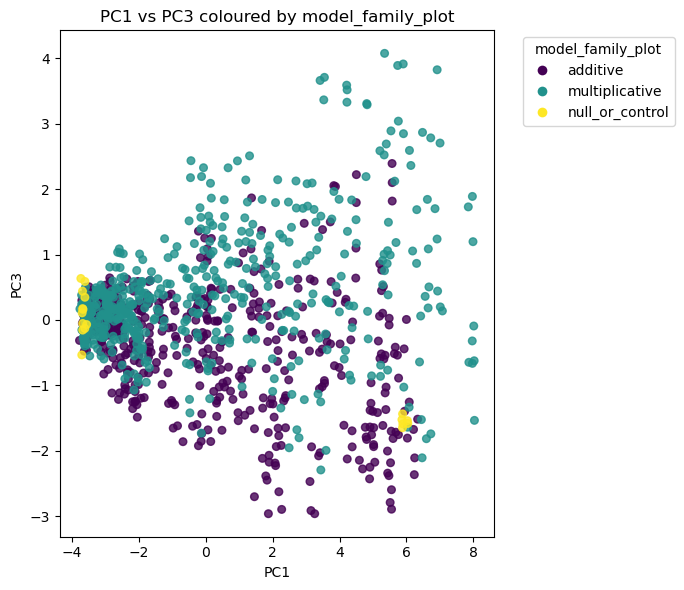

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc1_pc3_by_model_family.png


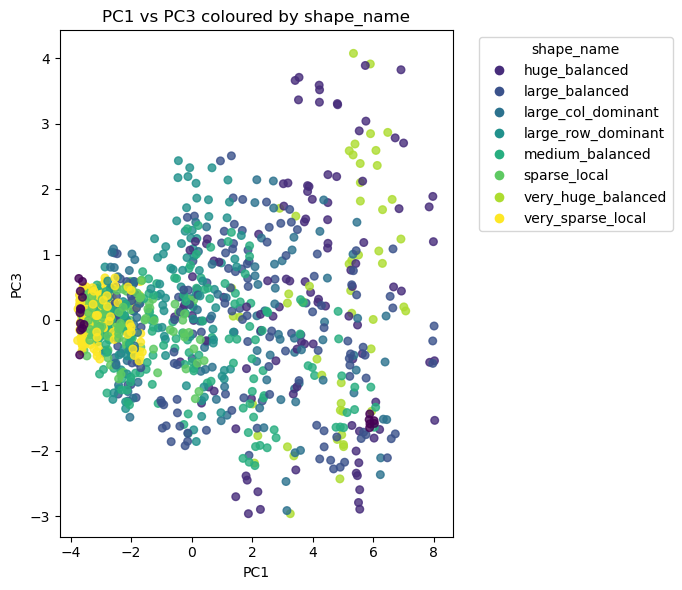

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc1_pc3_by_shape_name.png


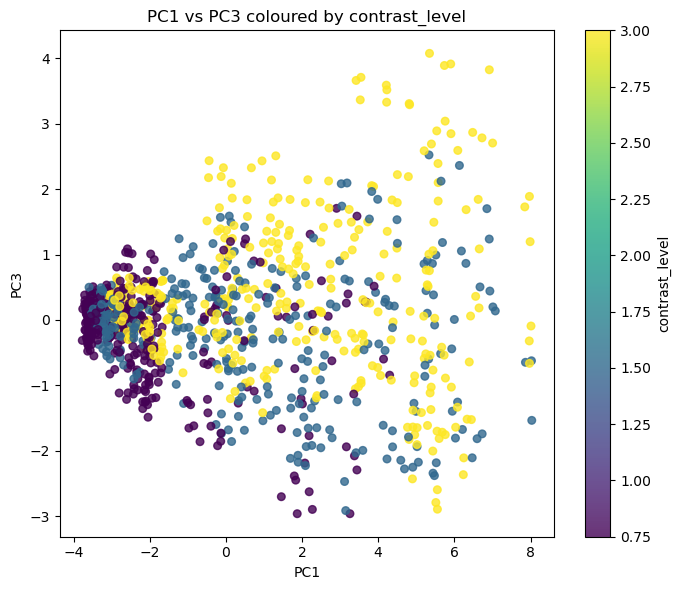

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc1_pc3_by_contrast_level.png


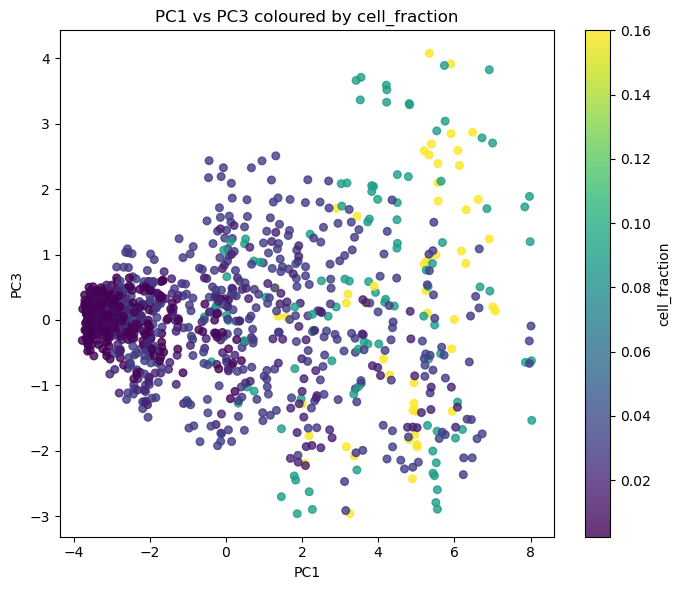

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc1_pc3_by_cell_fraction.png


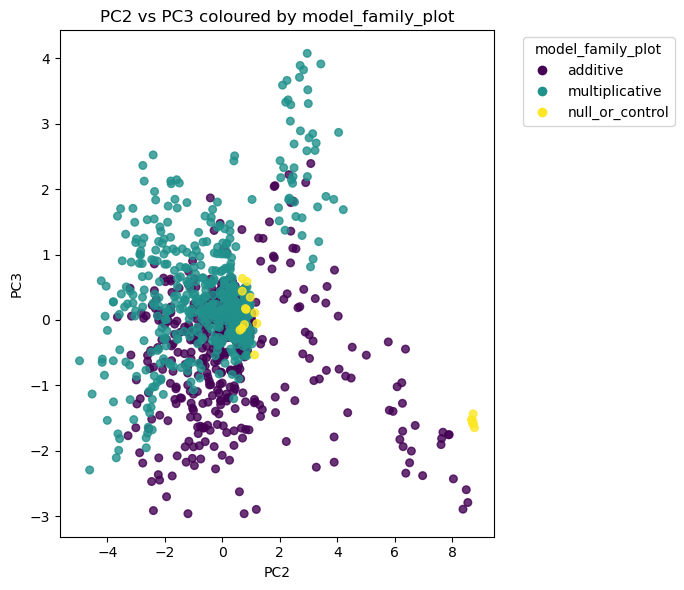

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc2_pc3_by_model_family.png


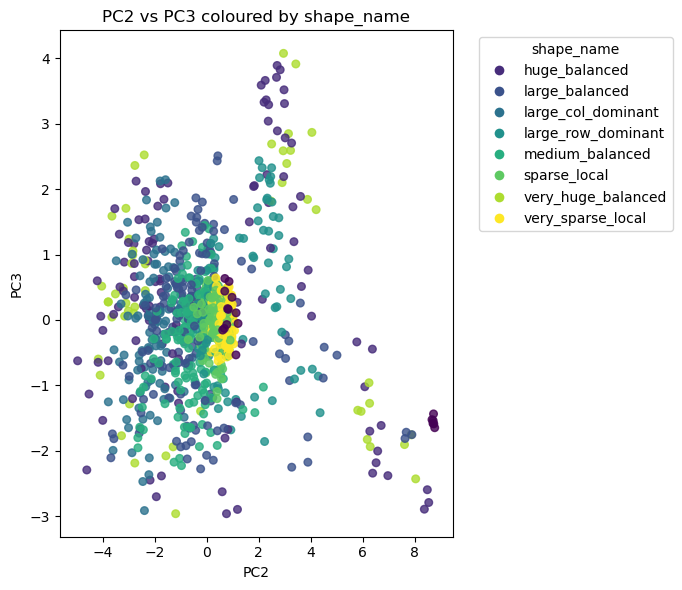

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc2_pc3_by_shape_name.png


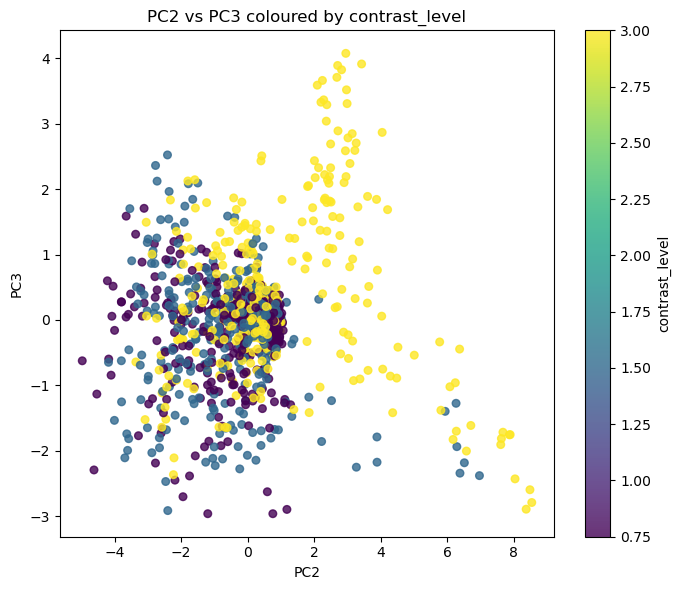

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc2_pc3_by_contrast_level.png


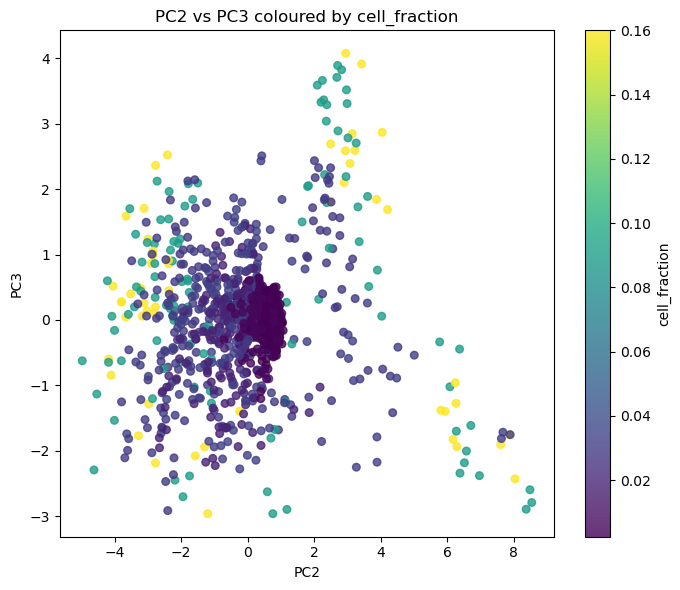

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc2_pc3_by_cell_fraction.png


In [7]:
# ============================================================
# Stage 5.6 Generate PC1/PC3 and PC2/PC3 plots
# ============================================================

for x_pc, y_pc in [("PC1", "PC3"), ("PC2", "PC3")]:
    if x_pc not in pca_scores.columns or y_pc not in pca_scores.columns:
        continue

    if "model_family_plot" in pca_scores.columns:
        plot_pc_categorical_colour(
            pca_scores,
            x_pc,
            y_pc,
            "model_family_plot",
            f"pca_{x_pc.lower()}_{y_pc.lower()}_by_model_family.png"
        )

    if "shape_name" in pca_scores.columns:
        plot_pc_categorical_colour(
            pca_scores,
            x_pc,
            y_pc,
            "shape_name",
            f"pca_{x_pc.lower()}_{y_pc.lower()}_by_shape_name.png"
        )

    if "contrast_level" in pca_scores.columns:
        plot_pc_numeric_colour(
            pca_scores,
            x_pc,
            y_pc,
            "contrast_level",
            f"pca_{x_pc.lower()}_{y_pc.lower()}_by_contrast_level.png"
        )

    if "cell_fraction" in pca_scores.columns:
        plot_pc_numeric_colour(
            pca_scores,
            x_pc,
            y_pc,
            "cell_fraction",
            f"pca_{x_pc.lower()}_{y_pc.lower()}_by_cell_fraction.png"
        )

Structured-only rows: 1026


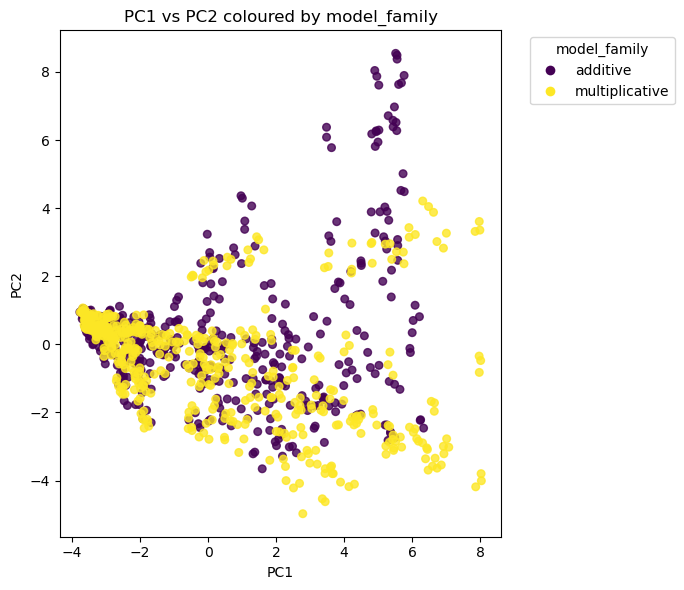

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc1_pc2_by_model_family_structured_only.png


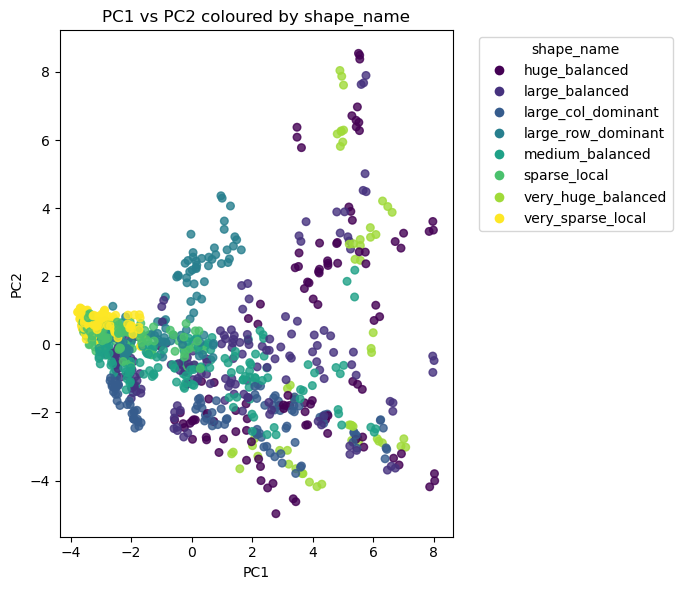

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc1_pc2_by_shape_name_structured_only.png


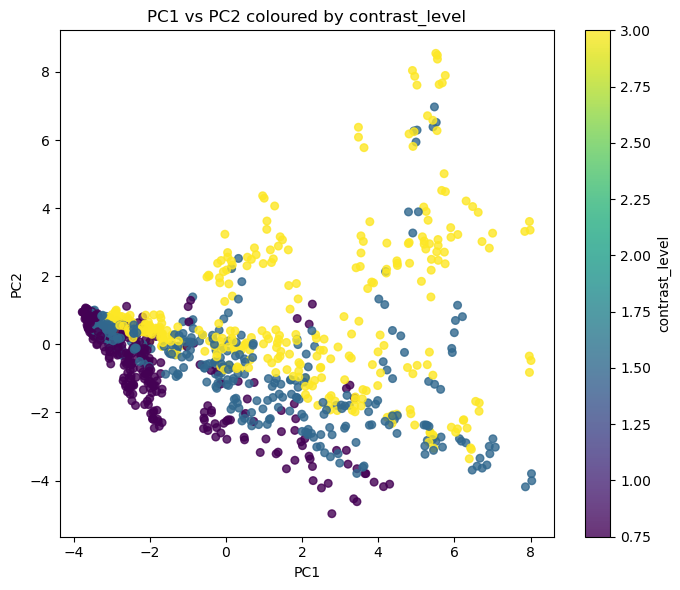

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc1_pc2_by_contrast_structured_only.png


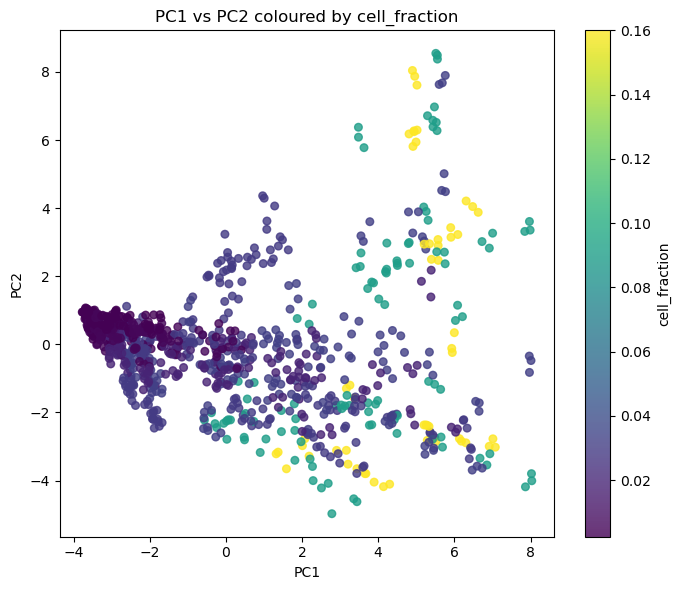

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pca_pc1_pc2_by_cell_fraction_structured_only.png


In [8]:
# ============================================================
# Stage 5.7 Structured-only PCA score plots
# ============================================================

if "dataset_type" in pca_scores.columns:
    structured_scores = pca_scores[pca_scores["dataset_type"] == "structured"].copy()
else:
    structured_scores = pca_scores[pca_scores["model_family"].notna()].copy()

print("Structured-only rows:", len(structured_scores))

if "model_family" in structured_scores.columns:
    plot_pc_categorical_colour(
        structured_scores,
        "PC1",
        "PC2",
        "model_family",
        "pca_pc1_pc2_by_model_family_structured_only.png"
    )

if "shape_name" in structured_scores.columns:
    plot_pc_categorical_colour(
        structured_scores,
        "PC1",
        "PC2",
        "shape_name",
        "pca_pc1_pc2_by_shape_name_structured_only.png"
    )

if "contrast_level" in structured_scores.columns:
    plot_pc_numeric_colour(
        structured_scores,
        "PC1",
        "PC2",
        "contrast_level",
        "pca_pc1_pc2_by_contrast_structured_only.png"
    )

if "cell_fraction" in structured_scores.columns:
    plot_pc_numeric_colour(
        structured_scores,
        "PC1",
        "PC2",
        "cell_fraction",
        "pca_pc1_pc2_by_cell_fraction_structured_only.png"
    )

In [9]:
# ============================================================
# Stage 5.8 Top positive and negative loadings for PC1 to PC5
# ============================================================

def get_top_loadings(loadings_df, pc, top_n=25):
    pc_loadings = loadings_df[pc].dropna().sort_values()

    negative = pc_loadings.head(top_n).reset_index()
    negative.columns = ["feature", "loading"]
    negative["PC"] = pc
    negative["direction"] = "negative"

    positive = pc_loadings.tail(top_n).sort_values(ascending=False).reset_index()
    positive.columns = ["feature", "loading"]
    positive["PC"] = pc
    positive["direction"] = "positive"

    return pd.concat([positive, negative], ignore_index=True)


top_loading_frames = []

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    if pc in loadings.columns:
        top_loading_frames.append(get_top_loadings(loadings, pc, top_n=25))

top_loadings_pc1_to_pc5 = pd.concat(top_loading_frames, ignore_index=True)
top_loadings_pc1_to_pc5.to_csv(TOP_LOADINGS_EXTENDED_PATH, index=False)

display(top_loadings_pc1_to_pc5)

print(f"Saved top loadings to: {TOP_LOADINGS_EXTENDED_PATH}")

,feature,loading,PC,direction
0,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,0.060873,PC1,positive
1,pyspoc.statistics.basic.Covariance.feature_cov...,0.060537,PC1,positive
2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,0.058761,PC1,positive
3,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058629,PC1,positive
4,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058449,PC1,positive
...,...,...,...,...
245,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.052021,PC5,negative
246,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.051968,PC5,negative
247,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.050834,PC5,negative
248,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.050809,PC5,negative


Saved top loadings to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/top_loadings_pc1_to_pc5.csv


In [10]:
# ============================================================
# Stage 5.9 Print compact loading summaries
# ============================================================

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    if pc not in loadings.columns:
        continue

    evr = explained_variance.loc[
        explained_variance["PC"] == pc,
        "explained_variance_ratio"
    ]

    evr_value = evr.iloc[0] if len(evr) else np.nan

    print("=" * 100)
    print(f"{pc} | explained variance ratio = {evr_value:.4f}")

    print("\nTop positive loadings:")
    display(
        top_loadings_pc1_to_pc5[
            (top_loadings_pc1_to_pc5["PC"] == pc)
            & (top_loadings_pc1_to_pc5["direction"] == "positive")
        ][["feature", "loading"]].head(10)
    )

    print("\nTop negative loadings:")
    display(
        top_loadings_pc1_to_pc5[
            (top_loadings_pc1_to_pc5["PC"] == pc)
            & (top_loadings_pc1_to_pc5["direction"] == "negative")
        ][["feature", "loading"]].head(10)
    )

PC1 | explained variance ratio = 0.1655

Top positive loadings:


,feature,loading
0,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,0.060873
1,pyspoc.statistics.basic.Covariance.feature_cov...,0.060537
2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,0.058761
3,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058629
4,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058449
5,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058449
6,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058308
7,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.058275
8,pyspoc.statistics.basic.KendallTau.feature_ken...,0.058233
9,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058162



Top negative loadings:


,feature,loading
25,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.058315
26,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.057412
27,pyspoc.statistics.basic.Precision.feature_prec...,-0.054811
28,pyspoc.statistics.basic.Covariance.feature_cov...,-0.050319
29,pyspoc.statistics.basic.Precision.feature_prec...,-0.047400
30,pyspoc.statistics.basic.Covariance.feature_cov...,-0.043650
31,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.036700
32,pyspoc.statistics.basic.Precision.feature_prec...,-0.035679
33,pyspoc.statistics.basic.Precision.feature_prec...,-0.035679
34,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.034470


PC2 | explained variance ratio = 0.0658

Top positive loadings:


...

,feature,loading
175,/Users/ilg/Desktop/year4/M4R/python_files/summ...,-0.098505
176,pyspoc.statistics.basic.Precision.feature_prec...,-0.090031
177,pyspoc.statistics.basic.Precision.feature_prec...,-0.085292
178,pyspoc.statistics.basic.Precision.feature_prec...,-0.085292
179,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,-0.068312
180,pyspoc.statistics.basic.Precision.feature_prec...,-0.066185
181,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,-0.065893
182,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,-0.065614
183,pyspoc.statistics.basic.Precision.feature_prec...,-0.065518
184,pyspoc.statistics.basic.Precision.feature_prec...,-0.065011


PC5 | explained variance ratio = 0.0129

Top positive loadings:


,feature,loading
200,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.092503
201,pyspoc.statistics.basic.Covariance.feature_cov...,0.086167
202,pyspoc.statistics.basic.KendallTau.feature_ken...,0.083658
203,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.081543
204,pyspoc.statistics.basic.Covariance.feature_cov...,0.080929
205,pyspoc.statistics.basic.KendallTau.feature_ken...,0.080635
206,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.079423
207,pyspoc.statistics.basic.KendallTau.feature_ken...,0.078719
208,pyspoc.statistics.basic.KendallTau.feature_ken...,0.075273
209,pyspoc.statistics.basic.KendallTau.feature_ken...,0.074961



Top negative loadings:


,feature,loading
225,/Users/ilg/Desktop/year4/M4R/python_files/summ...,-0.074022
226,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.067428
227,/Users/ilg/Desktop/year4/M4R/python_files/summ...,-0.064798
228,/Users/ilg/Desktop/year4/M4R/python_files/summ...,-0.063404
229,pyspoc.statistics.basic.Precision.feature_prec...,-0.063218
230,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.059608
231,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.059435
232,pyspoc.statistics.basic.Precision.feature_prec...,-0.058987
233,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.058052
234,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.056697


In [11]:
# ============================================================
# Stage 5.10 Loading dominance summary
# ============================================================

dominance_rows = []

for pc in pc_cols[:10]:
    if pc not in loadings.columns:
        continue

    abs_load = loadings[pc].abs().sort_values(ascending=False)
    total_abs = abs_load.sum()

    dominance_rows.append({
        "PC": pc,
        "top_1_abs_loading": abs_load.iloc[0],
        "top_1_abs_share": abs_load.iloc[:1].sum() / total_abs,
        "top_5_abs_share": abs_load.iloc[:5].sum() / total_abs,
        "top_10_abs_share": abs_load.iloc[:10].sum() / total_abs,
        "top_20_abs_share": abs_load.iloc[:20].sum() / total_abs,
        "top_50_abs_share": abs_load.iloc[:50].sum() / total_abs,
    })

loading_dominance = pd.DataFrame(dominance_rows)
loading_dominance.to_csv(LOADING_DOMINANCE_PATH, index=False)

display(loading_dominance)

print(f"Saved loading dominance summary to: {LOADING_DOMINANCE_PATH}")

,PC,top_1_abs_loading,top_1_abs_share,top_5_abs_share,top_10_abs_share,top_20_abs_share,top_50_abs_share
0,PC1,0.060873,0.002236,0.010921,0.021633,0.042833,0.102590
1,PC2,0.095207,0.004516,0.021495,0.042489,0.083532,0.201560
2,PC3,0.110755,0.003916,0.015939,0.029334,0.053270,0.117454
3,PC4,0.144665,0.005510,0.026478,0.046071,0.078624,0.151416
4,PC5,0.092503,0.003333,0.015305,0.029320,0.054760,0.123980
5,PC6,0.107100,0.003923,0.016820,0.031958,0.060329,0.133905
6,PC7,0.104408,0.003814,0.017602,0.032920,0.060343,0.129975
7,PC8,0.103175,0.003784,0.016858,0.031335,0.058070,0.129976
8,PC9,0.094891,0.003500,0.016272,0.031308,0.058611,0.130131
9,PC10,0.095057,0.003494,0.016385,0.030890,0.058487,0.130659


Saved loading dominance summary to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/loading_dominance_summary.csv


In [12]:
# ============================================================
# Stage 5.11 Assign feature families
# ============================================================

def assign_feature_family(feature_name):
    name = str(feature_name)

    if "PlaidAllMetrics" in name or "Plaid" in name:
        return "Plaid metrics"

    if "FABIAAllMetrics" in name or "FABIA" in name:
        return "FABIA metrics"

    if "DistanceDistributionBasicSummarize" in name:
        return "Distance distribution"

    if "DistanceDistributionModesSummarize" in name:
        return "Distance KDE/modes"

    if "GlobalMeanMedianDiff" in name:
        return "Global mean-median"

    if "PCAVarianceExplainedRatio" in name:
        return "PCA variance ratio statistic"

    if "PCAEigenVectors" in name:
        return "PCA eigenvectors statistic"

    if "Covariance" in name:
        return "Covariance-based"

    if "Precision" in name:
        return "Precision-based"

    if "KendallTau" in name:
        return "Kendall correlation"

    if "SpearmanR" in name:
        return "Spearman correlation"

    return "Other"


feature_families = pd.Series(
    {feature: assign_feature_family(feature) for feature in loadings.index},
    name="feature_family"
)

feature_families.value_counts()

feature_family
PCA eigenvectors statistic      300
Covariance-based                216
Precision-based                 216
Kendall correlation             213
Spearman correlation            213
Distance distribution            28
Plaid metrics                     9
FABIA metrics                     9
Distance KDE/modes                6
PCA variance ratio statistic      3
Global mean-median                1
Name: count, dtype: int64

In [13]:
# ============================================================
# Stage 5.12 Loading mass by feature family
# ============================================================

family_rows = []

for pc in pc_cols[:10]:
    if pc not in loadings.columns:
        continue

    abs_loadings = loadings[pc].abs()
    total_abs_loading = abs_loadings.sum()

    tmp = pd.DataFrame({
        "feature": loadings.index,
        "feature_family": feature_families.loc[loadings.index].values,
        "abs_loading": abs_loadings.values,
    })

    family_summary = (
        tmp.groupby("feature_family")["abs_loading"]
        .sum()
        .reset_index()
    )

    family_summary["PC"] = pc
    family_summary["abs_loading_share"] = (
        family_summary["abs_loading"] / total_abs_loading
    )

    family_rows.append(family_summary)

loading_family_summary = pd.concat(family_rows, ignore_index=True)
loading_family_summary = loading_family_summary.sort_values(
    ["PC", "abs_loading_share"],
    ascending=[True, False]
)

loading_family_summary.to_csv(LOADING_FAMILY_SUMMARY_PATH, index=False)

display(loading_family_summary.head(40))

print(f"Saved loading family summary to: {LOADING_FAMILY_SUMMARY_PATH}")

,feature_family,abs_loading,PC,abs_loading_share
0,Covariance-based,8.760088,PC1,0.321842
5,Kendall correlation,7.614144,PC1,0.279741
10,Spearman correlation,5.408143,PC1,0.198693
9,Precision-based,1.944836,PC1,0.071453
6,PCA eigenvectors statistic,1.563670,PC1,0.057449
2,Distance distribution,0.960140,PC1,0.035275
8,Plaid metrics,0.367822,PC1,0.013514
3,FABIA metrics,0.356490,PC1,0.013097
7,PCA variance ratio statistic,0.131707,PC1,0.004839
1,Distance KDE/modes,0.077925,PC1,0.002863


Saved loading family summary to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/loading_family_summary.csv


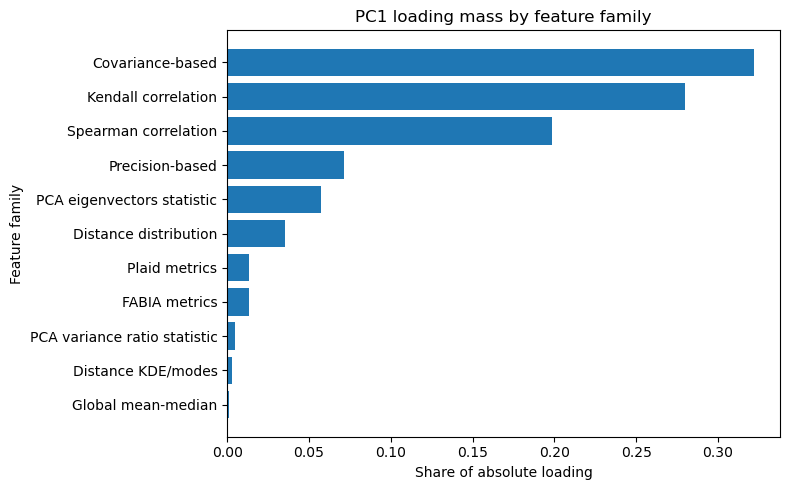

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pc1_loading_family_share.png


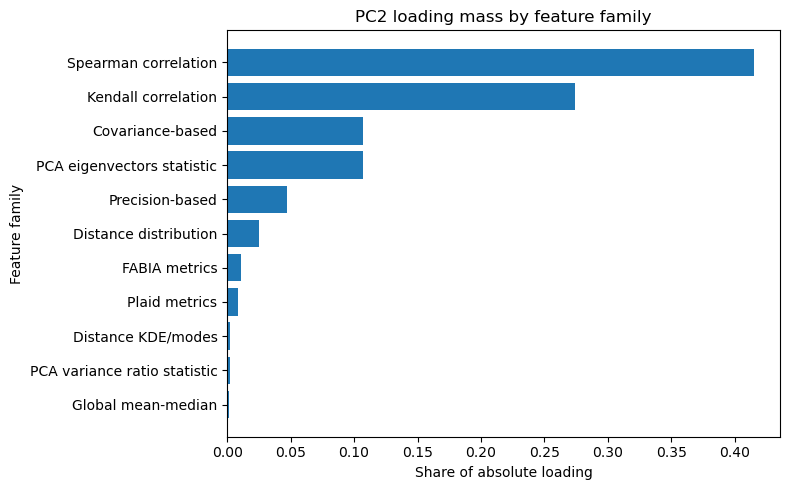

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pc2_loading_family_share.png


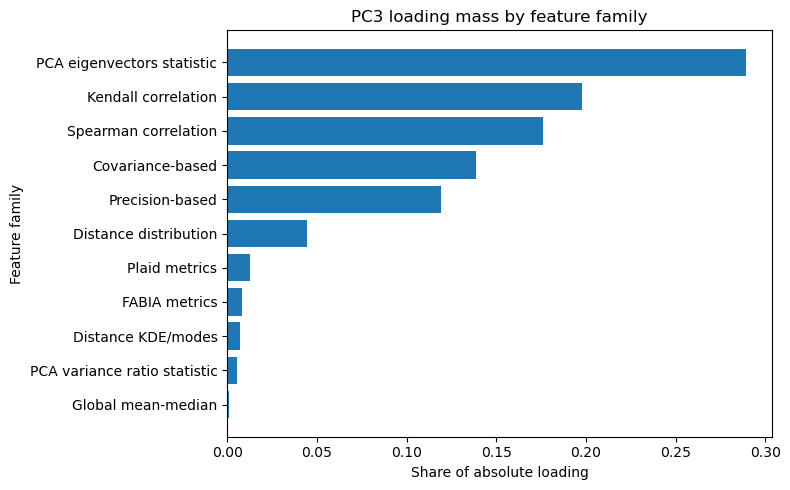

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pc3_loading_family_share.png


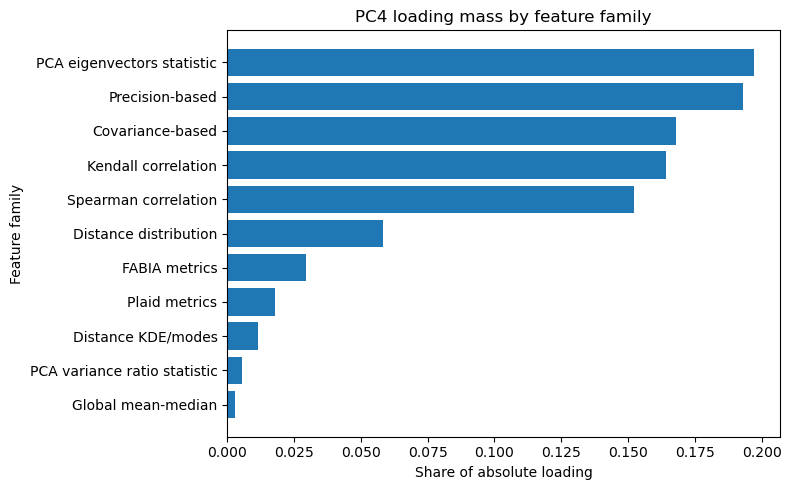

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pc4_loading_family_share.png


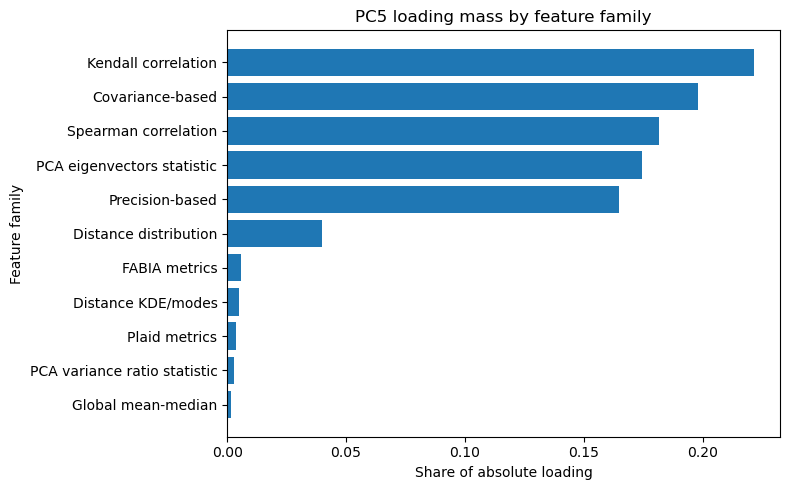

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/plots/pc5_loading_family_share.png


In [14]:
# ============================================================
# Stage 5.13 Plot loading family shares
# ============================================================

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    tmp = loading_family_summary[loading_family_summary["PC"] == pc].copy()

    if tmp.empty:
        continue

    tmp = tmp.sort_values("abs_loading_share", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(tmp["feature_family"], tmp["abs_loading_share"])
    plt.xlabel("Share of absolute loading")
    plt.ylabel("Feature family")
    plt.title(f"{pc} loading mass by feature family")
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"{pc.lower()}_loading_family_share.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")

In [15]:
# ============================================================
# Stage 5.14 Create compact interpretation summary
# ============================================================

summary_rows = []

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    if pc not in loadings.columns:
        continue

    evr = explained_variance.loc[
        explained_variance["PC"] == pc,
        "explained_variance_ratio"
    ]

    evr_value = evr.iloc[0] if len(evr) else np.nan

    top_meta = (
        pc_metadata_corr[pc_metadata_corr["PC"] == pc]
        .sort_values("abs_spearman_correlation", ascending=False)
        .head(3)
    )

    top_cat = (
        pc_categorical_effects[pc_categorical_effects["PC"] == pc]
        .sort_values("eta_squared", ascending=False)
        .head(3)
    )

    top_family = (
        loading_family_summary[loading_family_summary["PC"] == pc]
        .sort_values("abs_loading_share", ascending=False)
        .head(3)
    )

    summary_rows.append({
        "PC": pc,
        "explained_variance_ratio": evr_value,
        "top_continuous_metadata": "; ".join(
            f"{r.metadata_variable} ({r.spearman_correlation:.3f})"
            for r in top_meta.itertuples()
        ),
        "top_categorical_metadata": "; ".join(
            f"{r.metadata_variable} (eta2={r.eta_squared:.3f})"
            for r in top_cat.itertuples()
        ),
        "top_loading_families": "; ".join(
            f"{r.feature_family} ({r.abs_loading_share:.3f})"
            for r in top_family.itertuples()
        ),
    })

stage5_summary = pd.DataFrame(summary_rows)

STAGE5_SUMMARY_PATH = STAGE5_DIR / "stage5_pca_interpretation_summary.csv"
stage5_summary.to_csv(STAGE5_SUMMARY_PATH, index=False)

display(stage5_summary)

print(f"Saved Stage 5 summary to: {STAGE5_SUMMARY_PATH}")

,PC,explained_variance_ratio,top_continuous_metadata,top_categorical_metadata,top_loading_families
0,PC1,0.165506,approx_total_planted_fraction (0.813); col_fra...,shape_name (eta2=0.581); model_family_plot (et...,Covariance-based (0.322); Kendall correlation ...
1,PC2,0.065752,col_fraction (-0.475); approx_total_planted_fr...,shape_name (eta2=0.194); model_family_plot (et...,Spearman correlation (0.415); Kendall correlat...
2,PC3,0.017497,row_overlap_ratio (0.365); col_overlap_ratio (...,model_family_plot (eta2=0.150); shape_name (et...,PCA eigenvectors statistic (0.289); Kendall co...
3,PC4,0.014595,contrast_level (0.582); row_fraction (-0.290);...,shape_name (eta2=0.324); model_family_plot (et...,PCA eigenvectors statistic (0.197); Precision-...
4,PC5,0.012867,row_fraction (-0.206); cell_fraction (-0.192);...,shape_name (eta2=0.082); model_family_plot (et...,Kendall correlation (0.221); Covariance-based ...


Saved Stage 5 summary to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/05_pca_diagnosis/stage5_pca_interpretation_summary.csv


In [16]:
# ============================================================
# Stage 5 add-on: quantify contrast separation in PCA space
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

df_contrast = pca_scores.dropna(subset=["contrast_level"]).copy()
y = df_contrast["contrast_level"].astype(str)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

for pc_set in [
    ["PC1"],
    ["PC1", "PC2"],
    ["PC1", "PC2", "PC3"],
    ["PC1", "PC2", "PC3", "PC4", "PC5"],
]:
    X = df_contrast[pc_set]
    scores = cross_val_score(clf, X, y, cv=5)

    print(f"{pc_set}: accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

['PC1']: accuracy = 0.532 ± 0.043
['PC1', 'PC2']: accuracy = 0.616 ± 0.044
['PC1', 'PC2', 'PC3']: accuracy = 0.614 ± 0.027
['PC1', 'PC2', 'PC3', 'PC4', 'PC5']: accuracy = 0.816 ± 0.029


In [17]:
# ============================================================
# Stage 5 add-on: quantify shape separation in PCA space
# ============================================================

df_shape = pca_scores.dropna(subset=["shape_name"]).copy()
y = df_shape["shape_name"].astype(str)

for pc_set in [
    ["PC1"],
    ["PC1", "PC2"],
    ["PC1", "PC2", "PC3"],
    ["PC1", "PC2", "PC3", "PC4", "PC5"],
]:
    X = df_shape[pc_set]
    scores = cross_val_score(clf, X, y, cv=5)

    print(f"{pc_set}: accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

['PC1']: accuracy = 0.307 ± 0.076
['PC1', 'PC2']: accuracy = 0.405 ± 0.090
['PC1', 'PC2', 'PC3']: accuracy = 0.403 ± 0.069
['PC1', 'PC2', 'PC3', 'PC4', 'PC5']: accuracy = 0.529 ± 0.073


# stage 6

In [18]:
# ============================================================
# Stage 6. Load normalised features for feature-side analysis
# ============================================================

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

PROJECT_DIR = Path("/Users/ilg/Desktop/year4/M4R/python_files")
OUTPUT_DIR = PROJECT_DIR / "eda_output_unnormalised"

STAGE3_DIR = OUTPUT_DIR / "03_sigmoid_normalisation"
FEATURES_SIGMOID_PATH = STAGE3_DIR / "features_sigmoid_normalised.csv"
METADATA_STAGE3_PATH = STAGE3_DIR / "metadata_stage3.csv"

STAGE6_DIR = OUTPUT_DIR / "06_feature_side_analysis"
STAGE6_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = STAGE6_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_CORR_PATH = STAGE6_DIR / "feature_spearman_correlation_matrix.csv"
FEATURE_CLUSTER_PATH = STAGE6_DIR / "feature_clusters.csv"
HIGH_CORR_PAIRS_PATH = STAGE6_DIR / "highly_correlated_feature_pairs.csv"
FAMILY_CORR_PATH = STAGE6_DIR / "feature_family_correlation_summary.csv"
ALGORITHM_METRIC_NEIGHBOURS_PATH = STAGE6_DIR / "algorithm_metric_nearest_neighbours.csv"

features = pd.read_csv(FEATURES_SIGMOID_PATH)
metadata = pd.read_csv(METADATA_STAGE3_PATH)

print("features shape:", features.shape)
print("metadata shape:", metadata.shape)

features shape: (1044, 1214)
metadata shape: (1044, 15)


In [19]:
# ============================================================
# Stage 6.1 Assign feature families
# ============================================================

def assign_feature_family(feature_name):
    name = str(feature_name)

    if "PlaidAllMetrics" in name or "Plaid" in name:
        return "Plaid metrics"

    if "FABIAAllMetrics" in name or "FABIA" in name:
        return "FABIA metrics"

    if "DistanceDistributionBasicSummarize" in name:
        return "Distance distribution"

    if "DistanceDistributionModesSummarize" in name:
        return "Distance KDE/modes"

    if "GlobalMeanMedianDiff" in name:
        return "Global mean-median"

    if "PCAVarianceExplainedRatio" in name:
        return "PCA variance ratio statistic"

    if "PCAEigenVectors" in name:
        return "PCA eigenvectors statistic"

    if "Covariance" in name:
        return "Covariance-based"

    if "Precision" in name:
        return "Precision-based"

    if "KendallTau" in name:
        return "Kendall correlation"

    if "SpearmanR" in name:
        return "Spearman correlation"

    return "Other"


feature_info = pd.DataFrame({
    "feature": features.columns,
    "feature_family": [assign_feature_family(c) for c in features.columns],
})

display(feature_info["feature_family"].value_counts().to_frame("count"))

,count
feature_family,
PCA eigenvectors statistic,300
Covariance-based,216
Precision-based,216
Kendall correlation,213
Spearman correlation,213
Distance distribution,28
Plaid metrics,9
FABIA metrics,9
Distance KDE/modes,6


In [20]:
# ============================================================
# Stage 6.2 Compute feature-feature Spearman correlation
# ============================================================
# Rows are datasets, columns are features.
# This compares statistics by how similarly they vary across datasets.

feature_corr = features.corr(method="spearman")

# Numerical safety
feature_corr = feature_corr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
np.fill_diagonal(feature_corr.values, 1.0)

feature_corr.to_csv(FEATURE_CORR_PATH)

print("Feature correlation matrix shape:", feature_corr.shape)
print(f"Saved to: {FEATURE_CORR_PATH}")

Feature correlation matrix shape: (1214, 1214)
Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/feature_spearman_correlation_matrix.csv


In [21]:
# ============================================================
# Stage 6.3 Find highly correlated feature pairs
# ============================================================

HIGH_CORR_THRESHOLD = 0.95

corr_values = feature_corr.to_numpy()
feature_names = feature_corr.columns.to_numpy()

upper_i, upper_j = np.triu_indices_from(corr_values, k=1)
upper_corr = corr_values[upper_i, upper_j]

high_mask = np.abs(upper_corr) >= HIGH_CORR_THRESHOLD

high_corr_pairs = pd.DataFrame({
    "feature_1": feature_names[upper_i[high_mask]],
    "feature_2": feature_names[upper_j[high_mask]],
    "spearman_corr": upper_corr[high_mask],
    "abs_spearman_corr": np.abs(upper_corr[high_mask]),
})

high_corr_pairs["feature_1_family"] = high_corr_pairs["feature_1"].apply(assign_feature_family)
high_corr_pairs["feature_2_family"] = high_corr_pairs["feature_2"].apply(assign_feature_family)

high_corr_pairs = high_corr_pairs.sort_values(
    "abs_spearman_corr",
    ascending=False
)

high_corr_pairs.to_csv(HIGH_CORR_PAIRS_PATH, index=False)

print("Number of highly correlated pairs:", len(high_corr_pairs))
display(high_corr_pairs.head(30))

print(f"Saved to: {HIGH_CORR_PAIRS_PATH}")

Number of highly correlated pairs: 951


,feature_1,feature_2,spearman_corr,abs_spearman_corr,feature_1_family,feature_2_family
241,pyspoc.statistics.basic.Covariance.feature_cov...,pyspoc.statistics.basic.Covariance.feature_cov...,1.000000,1.000000,Covariance-based,Covariance-based
684,pyspoc.statistics.basic.KendallTau.feature_ken...,pyspoc.statistics.basic.KendallTau.feature_ken...,1.000000,1.000000,Kendall correlation,Kendall correlation
174,pyspoc.statistics.basic.Covariance.feature_cov...,pyspoc.statistics.basic.Covariance.feature_cov...,1.000000,1.000000,Covariance-based,Covariance-based
837,pyspoc.statistics.basic.SpearmanR.feature_spea...,pyspoc.statistics.basic.SpearmanR.feature_spea...,1.000000,1.000000,Spearman correlation,Spearman correlation
463,pyspoc.statistics.basic.Precision.feature_prec...,pyspoc.statistics.basic.Precision.feature_prec...,1.000000,1.000000,Precision-based,Precision-based
646,pyspoc.statistics.basic.KendallTau.feature_ken...,pyspoc.statistics.basic.KendallTau.feature_ken...,1.000000,1.000000,Kendall correlation,Kendall correlation
462,pyspoc.statistics.basic.Precision.feature_prec...,pyspoc.statistics.basic.Precision.feature_prec...,1.000000,1.000000,Precision-based,Precision-based
820,pyspoc.statistics.basic.SpearmanR.feature_spea...,pyspoc.statistics.basic.SpearmanR.feature_spea...,1.000000,1.000000,Spearman correlation,Spearman correlation
502,pyspoc.statistics.basic.KendallTau.feature_ken...,pyspoc.statistics.basic.KendallTau.feature_ken...,0.999954,0.999954,Kendall correlation,Kendall correlation
505,pyspoc.statistics.basic.KendallTau.feature_ken...,pyspoc.statistics.basic.KendallTau.feature_ken...,0.999954,0.999954,Kendall correlation,Kendall correlation


Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/highly_correlated_feature_pairs.csv


In [22]:
# ============================================================
# Stage 6.4 Hierarchical clustering of features
# ============================================================
# Distance = 1 - |correlation|.
# This clusters features that behave similarly or oppositely.

abs_corr = feature_corr.abs()
distance_matrix = 1.0 - abs_corr

# Force exact symmetry and zero diagonal
distance_matrix = (distance_matrix + distance_matrix.T) / 2
np.fill_diagonal(distance_matrix.values, 0.0)

condensed_distance = squareform(distance_matrix.to_numpy(), checks=False)

Z = linkage(condensed_distance, method="average")

# Threshold 0.10 means features with |rho| roughly above 0.90 tend to cluster.
CLUSTER_DISTANCE_THRESHOLD = 0.10

cluster_labels = fcluster(
    Z,
    t=CLUSTER_DISTANCE_THRESHOLD,
    criterion="distance"
)

feature_clusters = feature_info.copy()
feature_clusters["cluster_id"] = cluster_labels

cluster_sizes = (
    feature_clusters["cluster_id"]
    .value_counts()
    .rename_axis("cluster_id")
    .reset_index(name="cluster_size")
)

feature_clusters = feature_clusters.merge(cluster_sizes, on="cluster_id", how="left")
feature_clusters = feature_clusters.sort_values(
    ["cluster_size", "cluster_id", "feature_family"],
    ascending=[False, True, True]
)

feature_clusters.to_csv(FEATURE_CLUSTER_PATH, index=False)

print("Number of feature clusters:", feature_clusters["cluster_id"].nunique())
display(cluster_sizes.sort_values("cluster_size", ascending=False).head(20))
display(feature_clusters.head(30))

print(f"Saved to: {FEATURE_CLUSTER_PATH}")

Number of feature clusters: 840


,cluster_id,cluster_size
0,660,32
1,659,26
6,824,3
10,524,3
8,657,3
7,652,3
9,658,3
5,500,3
4,296,3
3,297,3


,feature,feature_family,cluster_id,cluster_size
0,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
3,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
4,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
205,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
206,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
207,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
208,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
209,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
210,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
213,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32


Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/feature_clusters.csv


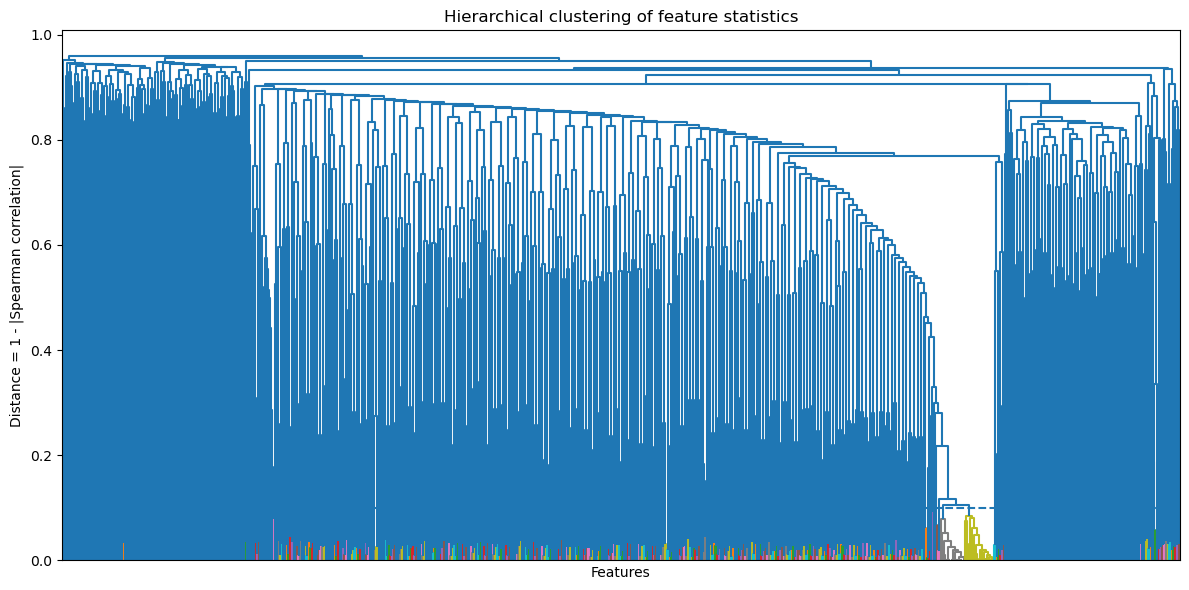

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/plots/feature_dendrogram_no_labels.png


In [23]:
# ============================================================
# Stage 6.5 Plot feature dendrogram
# ============================================================
# Full labels are unreadable for 1200+ features, so hide leaf labels.

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    no_labels=True,
    color_threshold=CLUSTER_DISTANCE_THRESHOLD
)
plt.axhline(CLUSTER_DISTANCE_THRESHOLD, linestyle="--")
plt.xlabel("Features")
plt.ylabel("Distance = 1 - |Spearman correlation|")
plt.title("Hierarchical clustering of feature statistics")
plt.tight_layout()

plot_path = PLOTS_DIR / "feature_dendrogram_no_labels.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Saved plot to: {plot_path}")

In [24]:
# ============================================================
# Stage 6.6 Family-level correlation summary
# ============================================================
# Summarise how strongly feature families correlate with each other.

families = feature_info["feature_family"].unique()
family_corr_rows = []

for fam1 in families:
    features_1 = feature_info.loc[
        feature_info["feature_family"] == fam1,
        "feature"
    ].tolist()

    for fam2 in families:
        features_2 = feature_info.loc[
            feature_info["feature_family"] == fam2,
            "feature"
        ].tolist()

        sub_corr = feature_corr.loc[features_1, features_2].abs().to_numpy().ravel()

        # Remove self-correlations for same-family summaries
        if fam1 == fam2:
            sub_corr = sub_corr[sub_corr < 0.999999]

        if len(sub_corr) == 0:
            median_abs_corr = np.nan
            mean_abs_corr = np.nan
        else:
            median_abs_corr = np.median(sub_corr)
            mean_abs_corr = np.mean(sub_corr)

        family_corr_rows.append({
            "family_1": fam1,
            "family_2": fam2,
            "median_abs_spearman_corr": median_abs_corr,
            "mean_abs_spearman_corr": mean_abs_corr,
        })

family_corr_summary = pd.DataFrame(family_corr_rows)
family_corr_summary.to_csv(FAMILY_CORR_PATH, index=False)

display(
    family_corr_summary.sort_values(
        "median_abs_spearman_corr",
        ascending=False
    ).head(30)
)

print(f"Saved to: {FAMILY_CORR_PATH}")

,family_1,family_2,median_abs_spearman_corr,mean_abs_spearman_corr
48,Plaid metrics,Plaid metrics,0.726505,0.725487
60,FABIA metrics,FABIA metrics,0.701560,0.682816
92,Global mean-median,Plaid metrics,0.634974,0.612283
52,Plaid metrics,Global mean-median,0.634974,0.612283
63,FABIA metrics,Global mean-median,0.634046,0.561235
93,Global mean-median,FABIA metrics,0.634046,0.561235
98,Global mean-median,PCA variance ratio statistic,0.626293,0.447718
118,PCA variance ratio statistic,Global mean-median,0.626293,0.447718
74,Distance distribution,Global mean-median,0.604087,0.522422
94,Global mean-median,Distance distribution,0.604087,0.522422


Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/feature_family_correlation_summary.csv


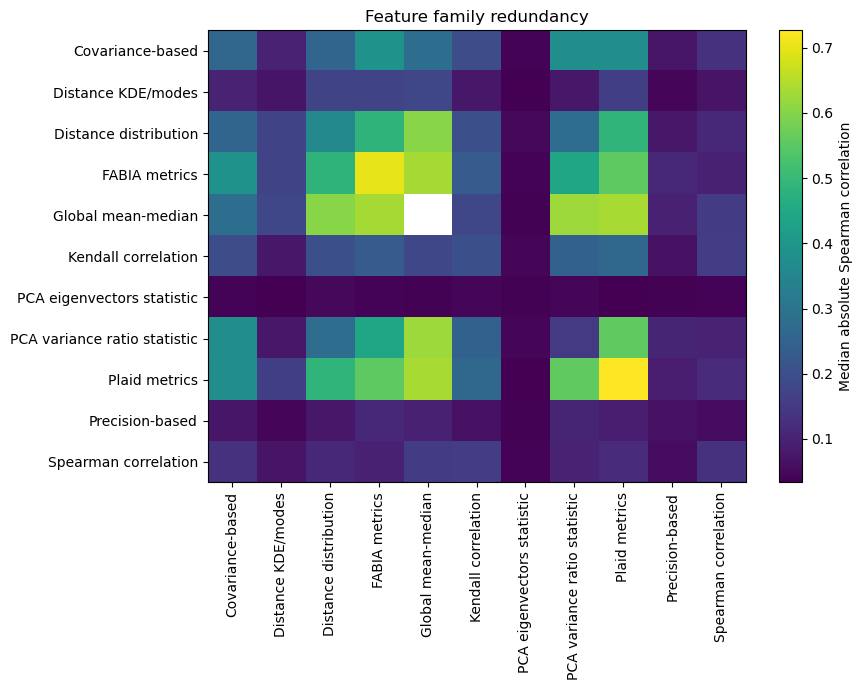

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/plots/feature_family_median_abs_correlation_heatmap.png


In [25]:
# ============================================================
# Stage 6.7 Plot family-level median absolute correlation heatmap
# ============================================================

family_heatmap = family_corr_summary.pivot(
    index="family_1",
    columns="family_2",
    values="median_abs_spearman_corr"
)

plt.figure(figsize=(9, 7))
plt.imshow(family_heatmap, aspect="auto")
plt.colorbar(label="Median absolute Spearman correlation")
plt.xticks(
    ticks=np.arange(len(family_heatmap.columns)),
    labels=family_heatmap.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(family_heatmap.index)),
    labels=family_heatmap.index
)
plt.title("Feature family redundancy")
plt.tight_layout()

plot_path = PLOTS_DIR / "feature_family_median_abs_correlation_heatmap.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {plot_path}")

In [26]:
# ============================================================
# Stage 6.8 Nearest neighbours of Plaid/FABIA metrics
# ============================================================
# This is important for your project:
# it tells whether your algorithm metrics are redundant with generic statistics.

algorithm_metric_features = [
    col for col in features.columns
    if ("PlaidAllMetrics" in col or "FABIAAllMetrics" in col or "Plaid" in col or "FABIA" in col)
]

print("Number of algorithm metric features:", len(algorithm_metric_features))
display(pd.DataFrame({"algorithm_metric_feature": algorithm_metric_features}))

neighbour_rows = []

TOP_N_NEIGHBOURS = 15

for metric_feature in algorithm_metric_features:
    corr_series = feature_corr[metric_feature].drop(index=metric_feature)
    corr_abs_sorted = corr_series.abs().sort_values(ascending=False)

    for rank, neighbour in enumerate(corr_abs_sorted.head(TOP_N_NEIGHBOURS).index, start=1):
        neighbour_rows.append({
            "algorithm_metric": metric_feature,
            "algorithm_metric_family": assign_feature_family(metric_feature),
            "rank": rank,
            "neighbour_feature": neighbour,
            "neighbour_family": assign_feature_family(neighbour),
            "spearman_corr": corr_series.loc[neighbour],
            "abs_spearman_corr": abs(corr_series.loc[neighbour]),
        })

algorithm_metric_neighbours = pd.DataFrame(neighbour_rows)
algorithm_metric_neighbours.to_csv(ALGORITHM_METRIC_NEIGHBOURS_PATH, index=False)

display(algorithm_metric_neighbours.head(50))

print(f"Saved to: {ALGORITHM_METRIC_NEIGHBOURS_PATH}")

Number of algorithm metric features: 18


,algorithm_metric_feature
0,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
3,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
4,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
5,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
6,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
7,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
8,/Users/ilg/Desktop/year4/M4R/python_files/Plai...
9,/Users/ilg/Desktop/year4/M4R/python_files/FABI...


,algorithm_metric,algorithm_metric_family,rank,neighbour_feature,neighbour_family,spearman_corr,abs_spearman_corr
0,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.988179,0.988179
1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.979925,0.979925
2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,3,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.932140,0.932140
3,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,4,pyspoc.rstatistics.pca.PCAVarianceExplainedRat...,PCA variance ratio statistic,0.930341,0.930341
4,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,5,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928595,0.928595
5,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,6,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928595,0.928595
6,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,7,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928520,0.928520
7,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,8,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.924909,0.924909
8,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,9,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,-0.923485,0.923485
9,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,10,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.923256,0.923256


Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/algorithm_metric_nearest_neighbours.csv


In [27]:
# ============================================================
# Stage 6.9 Which clusters contain algorithm metrics?
# ============================================================

algorithm_metric_clusters = feature_clusters[
    feature_clusters["feature"].isin(algorithm_metric_features)
].copy()

display(algorithm_metric_clusters)

for cluster_id in algorithm_metric_clusters["cluster_id"].unique():
    print("=" * 100)
    print(f"Cluster {cluster_id}")
    cluster_members = feature_clusters[
        feature_clusters["cluster_id"] == cluster_id
    ].copy()

    print("Cluster size:", len(cluster_members))
    print(cluster_members["feature_family"].value_counts())

    display(cluster_members.head(30))

,feature,feature_family,cluster_id,cluster_size
867,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,660,32
869,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,660,32
870,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,660,32
872,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,660,32
873,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,660,32
875,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,660,32
859,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,660,32
862,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,660,32
865,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,660,32
858,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,658,3


Cluster 660
Cluster size: 32
feature_family
Covariance-based                12
Distance distribution            6
FABIA metrics                    6
Plaid metrics                    3
Precision-based                  3
PCA variance ratio statistic     2
Name: count, dtype: int64


,feature,feature_family,cluster_id,cluster_size
0,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
3,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
4,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
205,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
206,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
207,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
208,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
209,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
210,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32
213,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32


Cluster 658
Cluster size: 3
feature_family
Plaid metrics    3
Name: count, dtype: int64


,feature,feature_family,cluster_id,cluster_size
858,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,658,3
861,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,658,3
864,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,658,3


...

,feature,feature_family,cluster_id,cluster_size
863,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,212,1


Cluster 213
Cluster size: 1
feature_family
Plaid metrics    1
Name: count, dtype: int64


,feature,feature_family,cluster_id,cluster_size
866,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,213,1


Cluster 218
Cluster size: 1
feature_family
FABIA metrics    1
Name: count, dtype: int64


,feature,feature_family,cluster_id,cluster_size
868,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,218,1


In [28]:
# ============================================================
# Stage 6.10 Compact Stage 6 summary
# ============================================================

print("Stage 6 summary")
print("---------------")
print("Total features:", features.shape[1])
print("Number of high-correlation pairs |rho| >= 0.95:", len(high_corr_pairs))
print("Number of feature clusters:", feature_clusters["cluster_id"].nunique())
print("Number of algorithm metric features:", len(algorithm_metric_features))

print("\nLargest clusters:")
display(cluster_sizes.sort_values("cluster_size", ascending=False).head(10))

print("\nAlgorithm metric nearest neighbours:")
display(algorithm_metric_neighbours.head(30))

Stage 6 summary
---------------
Total features: 1214
Number of high-correlation pairs |rho| >= 0.95: 951
Number of feature clusters: 840
Number of algorithm metric features: 18

Largest clusters:


,cluster_id,cluster_size
0,660,32
1,659,26
6,824,3
10,524,3
8,657,3
7,652,3
9,658,3
5,500,3
4,296,3
3,297,3



Algorithm metric nearest neighbours:


,algorithm_metric,algorithm_metric_family,rank,neighbour_feature,neighbour_family,spearman_corr,abs_spearman_corr
0,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.988179,0.988179
1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.979925,0.979925
2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,3,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.932140,0.932140
3,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,4,pyspoc.rstatistics.pca.PCAVarianceExplainedRat...,PCA variance ratio statistic,0.930341,0.930341
4,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,5,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928595,0.928595
5,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,6,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928595,0.928595
6,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,7,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928520,0.928520
7,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,8,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.924909,0.924909
8,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,9,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,-0.923485,0.923485
9,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,10,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.923256,0.923256


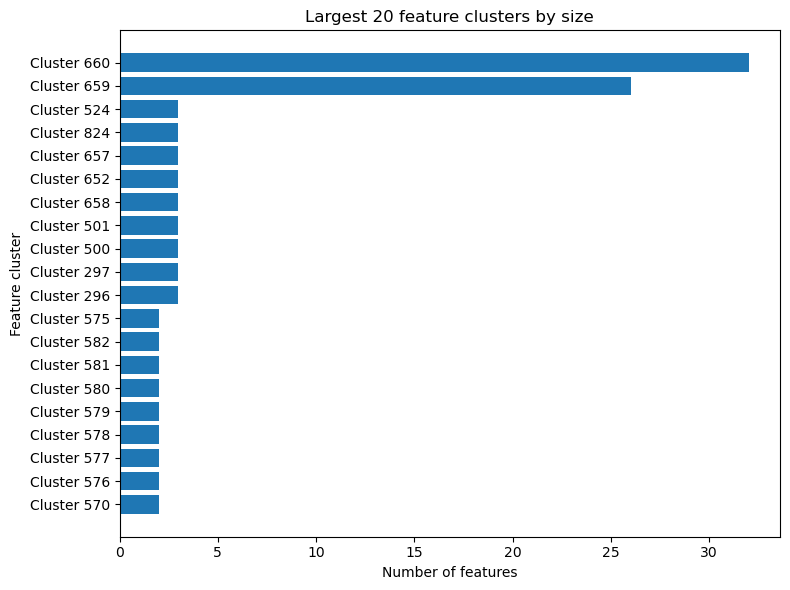

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/plots/largest_20_feature_clusters.png


In [29]:
# ============================================================
# Stage 6.11 Plot largest 20 feature clusters by size
# ============================================================

TOP_N_CLUSTERS = 20

largest_clusters = (
    feature_clusters[["cluster_id", "cluster_size"]]
    .drop_duplicates()
    .sort_values("cluster_size", ascending=False)
    .head(TOP_N_CLUSTERS)
    .copy()
)

largest_clusters["cluster_label"] = largest_clusters["cluster_id"].apply(
    lambda x: f"Cluster {x}"
)

plt.figure(figsize=(8, 6))
plt.barh(
    largest_clusters["cluster_label"][::-1],
    largest_clusters["cluster_size"][::-1],
)
plt.xlabel("Number of features")
plt.ylabel("Feature cluster")
plt.title("Largest 20 feature clusters by size")
plt.tight_layout()

plot_path = PLOTS_DIR / "largest_20_feature_clusters.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {plot_path}")

largest_clusters.to_csv(
    STAGE6_DIR / "largest_20_feature_clusters.csv",
    index=False
)

In [30]:
# ============================================================
# Stage 6.12 Clusters containing Plaid/FABIA metrics
# ============================================================

algorithm_metric_clusters = feature_clusters[
    feature_clusters["feature"].isin(algorithm_metric_features)
].copy()

algorithm_cluster_ids = algorithm_metric_clusters["cluster_id"].unique()

algorithm_cluster_summary_rows = []

for cluster_id in algorithm_cluster_ids:
    members = feature_clusters[feature_clusters["cluster_id"] == cluster_id].copy()

    family_counts = (
        members["feature_family"]
        .value_counts()
        .to_dict()
    )

    algorithm_members = members[
        members["feature"].isin(algorithm_metric_features)
    ]["feature"].tolist()

    algorithm_cluster_summary_rows.append({
        "cluster_id": cluster_id,
        "cluster_size": len(members),
        "algorithm_metric_count": len(algorithm_members),
        "algorithm_metrics_in_cluster": "; ".join(algorithm_members),
        "feature_family_counts": str(family_counts),
    })

algorithm_cluster_summary = pd.DataFrame(
    algorithm_cluster_summary_rows
).sort_values(
    ["algorithm_metric_count", "cluster_size"],
    ascending=[False, False]
)

algorithm_cluster_summary_path = STAGE6_DIR / "clusters_containing_algorithm_metrics.csv"
algorithm_cluster_summary.to_csv(algorithm_cluster_summary_path, index=False)

display(algorithm_cluster_summary)

print(f"Saved to: {algorithm_cluster_summary_path}")

,cluster_id,cluster_size,algorithm_metric_count,algorithm_metrics_in_cluster,feature_family_counts
0,660,32,9,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,"{'Covariance-based': 12, 'Distance distributio..."
1,658,3,3,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,{'Plaid metrics': 3}
2,217,2,2,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,{'FABIA metrics': 2}
3,211,1,1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,{'Plaid metrics': 1}
4,212,1,1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,{'Plaid metrics': 1}
5,213,1,1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,{'Plaid metrics': 1}
6,218,1,1,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,{'FABIA metrics': 1}


Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/clusters_containing_algorithm_metrics.csv


In [31]:
# ============================================================
# Stage 6.13 Full members of clusters containing Plaid/FABIA metrics
# ============================================================

algorithm_cluster_members = feature_clusters[
    feature_clusters["cluster_id"].isin(algorithm_cluster_ids)
].copy()

algorithm_cluster_members = algorithm_cluster_members.sort_values(
    ["cluster_id", "feature_family", "feature"]
)

algorithm_cluster_members_path = STAGE6_DIR / "members_of_algorithm_metric_clusters.csv"
algorithm_cluster_members.to_csv(algorithm_cluster_members_path, index=False)

display(algorithm_cluster_members.head(80))

print(f"Saved to: {algorithm_cluster_members_path}")

,feature,feature_family,cluster_id,cluster_size
860,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,211,1
863,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,212,1
866,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,213,1
871,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,217,2
874,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,217,2
868,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,218,1
858,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,658,3
861,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,658,3
864,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,658,3
214,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,660,32


Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/members_of_algorithm_metric_clusters.csv


In [32]:
# ============================================================
# Stage 6.14 Compact nearest-neighbour table for Plaid/FABIA metrics
# ============================================================

TOP_N_DISPLAY = 10

compact_neighbours = algorithm_metric_neighbours[
    algorithm_metric_neighbours["rank"] <= TOP_N_DISPLAY
].copy()

compact_neighbours = compact_neighbours[
    [
        "algorithm_metric",
        "rank",
        "neighbour_feature",
        "neighbour_family",
        "spearman_corr",
        "abs_spearman_corr",
    ]
]

compact_neighbours_path = STAGE6_DIR / "algorithm_metric_top10_neighbours.csv"
compact_neighbours.to_csv(compact_neighbours_path, index=False)

display(compact_neighbours)

print(f"Saved to: {compact_neighbours_path}")

,algorithm_metric,rank,neighbour_feature,neighbour_family,spearman_corr,abs_spearman_corr
0,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.988179,0.988179
1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.979925,0.979925
2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,3,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.932140,0.932140
3,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,4,pyspoc.rstatistics.pca.PCAVarianceExplainedRat...,PCA variance ratio statistic,0.930341,0.930341
4,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,5,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928595,0.928595
...,...,...,...,...,...,...
260,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,6,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,-0.990120,0.990120
261,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,7,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.990045,0.990045
262,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,8,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.990045,0.990045
263,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,9,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.985861,0.985861


Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/algorithm_metric_top10_neighbours.csv


In [33]:
# ============================================================
# Stage 6.15 Print nearest neighbours metric by metric
# ============================================================

for metric in algorithm_metric_features:
    print("=" * 120)
    print(metric)

    tmp = compact_neighbours[
        compact_neighbours["algorithm_metric"] == metric
    ].copy()

    display(
        tmp[
            [
                "rank",
                "neighbour_feature",
                "neighbour_family",
                "spearman_corr",
                "abs_spearman_corr",
            ]
        ]
    )

/Users/ilg/Desktop/year4/M4R/python_files/Plaid_metrics/Plaid_metrics.py.PlaidAllMetrics.assumed_k2.self_1


,rank,neighbour_feature,neighbour_family,spearman_corr,abs_spearman_corr
0,1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.988179,0.988179
1,2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.979925,0.979925
2,3,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.932140,0.932140
3,4,pyspoc.rstatistics.pca.PCAVarianceExplainedRat...,PCA variance ratio statistic,0.930341,0.930341
4,5,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928595,0.928595
5,6,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928595,0.928595
6,7,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.928520,0.928520
7,8,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.924909,0.924909
8,9,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,-0.923485,0.923485
9,10,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.923256,0.923256


/Users/ilg/Desktop/year4/M4R/python_files/Plaid_metrics/Plaid_metrics.py.PlaidAllMetrics.assumed_k2.self_2


,rank,neighbour_feature,neighbour_family,spearman_corr,abs_spearman_corr
15,1,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.996422,0.996422
16,2,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.993931,0.993931
17,3,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.993496,0.993496
18,4,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.993435,0.993435
19,5,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.991363,0.991363
20,6,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.986654,0.986654
21,7,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.986654,0.986654
22,8,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.985344,0.985344
23,9,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.985288,0.985288
24,10,pyspoc.statistics.basic.Precision.feature_prec...,Precision-based,0.983208,0.983208


/Users/ilg/Desktop/year4/M4R/python_files/Plaid_metrics/Plaid_metrics.py.PlaidAllMetrics.assumed_k2.self_3


...

,rank,neighbour_feature,neighbour_family,spearman_corr,abs_spearman_corr
225,1,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.991742,0.991742
226,2,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.976250,0.976250
227,3,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,-0.969565,0.969565
228,4,pyspoc.statistics.basic.Precision.feature_prec...,Precision-based,0.967981,0.967981
229,5,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.952227,0.952227
230,6,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.951937,0.951937
231,7,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.950750,0.950750
232,8,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.949370,0.949370
233,9,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.948965,0.948965
234,10,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.945222,0.945222


/Users/ilg/Desktop/year4/M4R/python_files/FABIA_metrics/FABIA_metrics.py.FABIAAllMetrics.assumed_k5.self_2


,rank,neighbour_feature,neighbour_family,spearman_corr,abs_spearman_corr
240,1,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.922133,0.922133
241,2,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.827246,0.827246
242,3,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.820815,0.820815
243,4,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.676116,0.676116
244,5,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.660150,0.660150
245,6,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.634434,0.634434
246,7,pyspoc.statistics.basic.Precision.feature_prec...,Precision-based,-0.602031,0.602031
247,8,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.582305,0.582305
248,9,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.580270,0.580270
249,10,pyspoc.statistics.basic.Precision.feature_prec...,Precision-based,-0.571832,0.571832


/Users/ilg/Desktop/year4/M4R/python_files/FABIA_metrics/FABIA_metrics.py.FABIAAllMetrics.assumed_k5.self_3


,rank,neighbour_feature,neighbour_family,spearman_corr,abs_spearman_corr
255,1,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.996696,0.996696
256,2,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.991576,0.991576
257,3,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.990676,0.990676
258,4,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.990671,0.990671
259,5,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.990411,0.990411
260,6,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,-0.990120,0.990120
261,7,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.990045,0.990045
262,8,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.990045,0.990045
263,9,/Users/ilg/Desktop/year4/M4R/python_files/FABI...,FABIA metrics,0.985861,0.985861
264,10,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.985344,0.985344


In [34]:
# ============================================================
# Stage 6.16 Choose one representative feature per cluster
# ============================================================

representative_rows = []

for cluster_id, cluster_df in feature_clusters.groupby("cluster_id"):
    cluster_features = cluster_df["feature"].tolist()

    if len(cluster_features) == 1:
        representative_feature = cluster_features[0]
        mean_abs_corr_to_cluster = 1.0
    else:
        sub_corr = feature_corr.loc[cluster_features, cluster_features].abs()

        # Exclude self-correlation by setting diagonal to NaN
        sub_corr_values = sub_corr.copy()
        np.fill_diagonal(sub_corr_values.values, np.nan)

        mean_abs_corr = sub_corr_values.mean(axis=1)
        representative_feature = mean_abs_corr.idxmax()
        mean_abs_corr_to_cluster = mean_abs_corr.loc[representative_feature]

    representative_rows.append({
        "cluster_id": cluster_id,
        "cluster_size": len(cluster_features),
        "representative_feature": representative_feature,
        "representative_family": assign_feature_family(representative_feature),
        "mean_abs_corr_to_cluster": mean_abs_corr_to_cluster,
    })

cluster_representatives = pd.DataFrame(representative_rows).sort_values(
    "cluster_size",
    ascending=False
)

cluster_representatives_path = STAGE6_DIR / "cluster_representative_features.csv"
cluster_representatives.to_csv(cluster_representatives_path, index=False)

display(cluster_representatives.head(30))

print(f"Saved to: {cluster_representatives_path}")

,cluster_id,cluster_size,representative_feature,representative_family,mean_abs_corr_to_cluster
659,660,32,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.972430
658,659,26,pyspoc.statistics.basic.KendallTau.feature_ken...,Kendall correlation,0.983483
651,652,3,pyspoc.statistics.basic.Precision.feature_prec...,Precision-based,0.969172
523,524,3,/Users/ilg/Desktop/year4/M4R/python_files/summ...,Distance distribution,0.979351
823,824,3,pyspoc.statistics.basic.Precision.feature_prec...,Precision-based,0.970933
500,501,3,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.980257
656,657,3,pyspoc.statistics.basic.KendallTau.feature_ken...,Kendall correlation,0.965789
499,500,3,pyspoc.statistics.basic.Precision.feature_prec...,Precision-based,0.988197
657,658,3,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,Plaid metrics,0.985558
296,297,3,pyspoc.statistics.basic.Covariance.feature_cov...,Covariance-based,0.983663


Saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/cluster_representative_features.csv


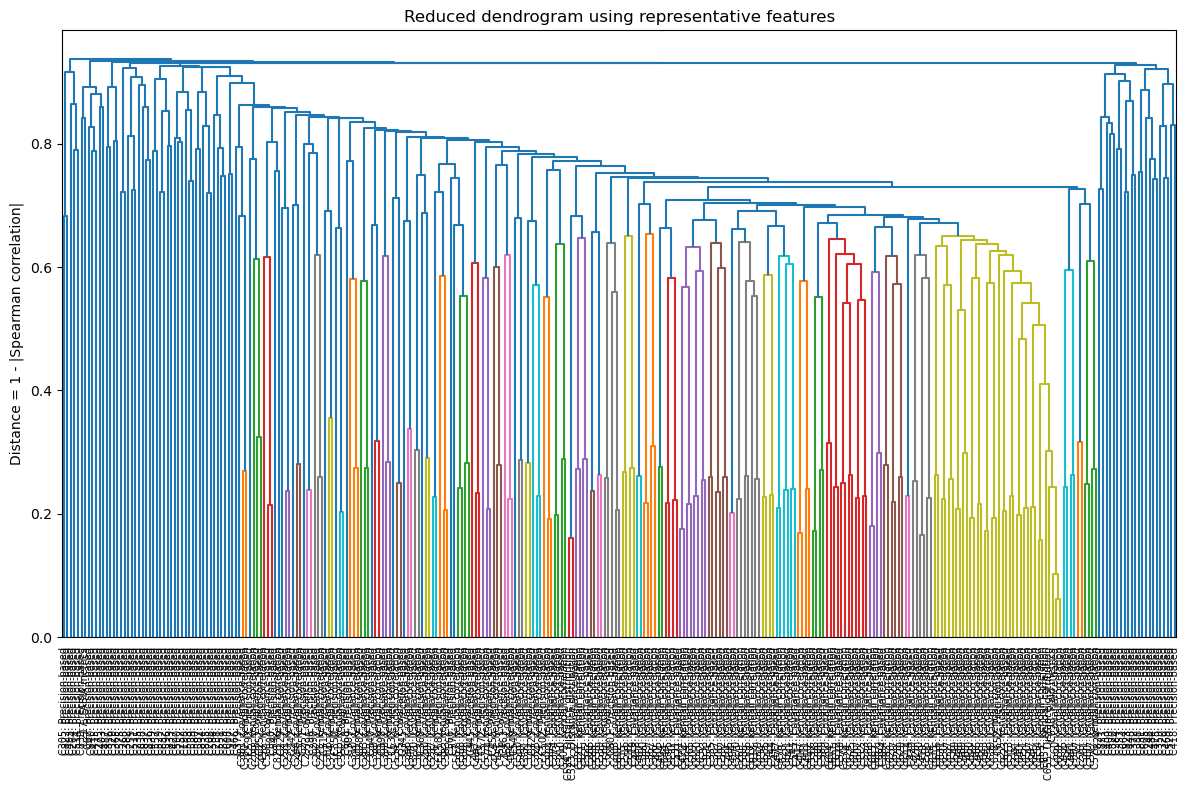

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/plots/reduced_dendrogram_cluster_representatives.png


In [35]:
# ============================================================
# Stage 6.17 Reduced dendrogram using cluster representatives
# ============================================================

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Use representatives from clusters with at least 2 features.
# You can include singleton clusters too, but it may still be too crowded.
MIN_CLUSTER_SIZE_FOR_REPRESENTATIVE = 2

rep_features = cluster_representatives[
    cluster_representatives["cluster_size"] >= MIN_CLUSTER_SIZE_FOR_REPRESENTATIVE
]["representative_feature"].tolist()

rep_feature_corr = feature_corr.loc[rep_features, rep_features].abs()
rep_distance = 1.0 - rep_feature_corr

rep_distance = (rep_distance + rep_distance.T) / 2
np.fill_diagonal(rep_distance.values, 0.0)

rep_condensed_distance = squareform(rep_distance.to_numpy(), checks=False)
Z_rep = linkage(rep_condensed_distance, method="average")

# Make shorter labels: family + cluster id
rep_labels_df = cluster_representatives.set_index("representative_feature").loc[rep_features]

rep_labels = [
    f"C{row.cluster_id}: {row.representative_family}"
    for row in rep_labels_df.itertuples()
]

plt.figure(figsize=(12, 8))
dendrogram(
    Z_rep,
    labels=rep_labels,
    leaf_rotation=90,
    leaf_font_size=7,
)
plt.ylabel("Distance = 1 - |Spearman correlation|")
plt.title("Reduced dendrogram using representative features")
plt.tight_layout()

plot_path = PLOTS_DIR / "reduced_dendrogram_cluster_representatives.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {plot_path}")

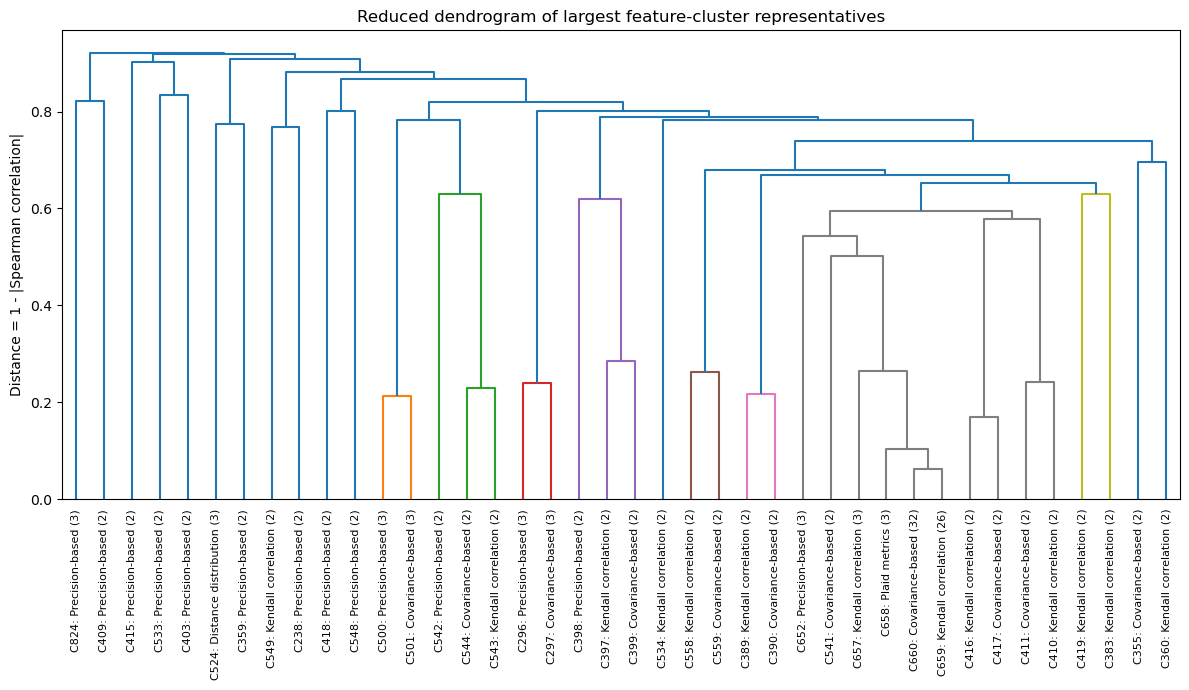

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/06_feature_side_analysis/plots/reduced_dendrogram_largest_cluster_representatives.png


In [36]:
# ============================================================
# Stage 6.18 Reduced dendrogram for largest cluster representatives only
# ============================================================

TOP_N_REP_CLUSTERS = 40

top_rep_features = (
    cluster_representatives
    .sort_values("cluster_size", ascending=False)
    .head(TOP_N_REP_CLUSTERS)
    ["representative_feature"]
    .tolist()
)

top_rep_corr = feature_corr.loc[top_rep_features, top_rep_features].abs()
top_rep_distance = 1.0 - top_rep_corr

top_rep_distance = (top_rep_distance + top_rep_distance.T) / 2
np.fill_diagonal(top_rep_distance.values, 0.0)

top_rep_condensed_distance = squareform(top_rep_distance.to_numpy(), checks=False)
Z_top_rep = linkage(top_rep_condensed_distance, method="average")

top_rep_labels_df = cluster_representatives.set_index("representative_feature").loc[top_rep_features]

top_rep_labels = [
    f"C{row.cluster_id}: {row.representative_family} ({row.cluster_size})"
    for row in top_rep_labels_df.itertuples()
]

plt.figure(figsize=(12, 7))
dendrogram(
    Z_top_rep,
    labels=top_rep_labels,
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.ylabel("Distance = 1 - |Spearman correlation|")
plt.title("Reduced dendrogram of largest feature-cluster representatives")
plt.tight_layout()

plot_path = PLOTS_DIR / "reduced_dendrogram_largest_cluster_representatives.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {plot_path}")